# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Febrian Rizky Anugrah
- **Email:** [febriabi13@gmail.com]
- **ID Dicoding:** [abongzzz]

**Dataset:** Capital Bikeshare, Washington D.C. (2011–2012)  
**Sumber data:** "day.csv" dan "hour.csv" yang disediakan pada proyek.


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

Berdasarkan karakteristik dataset dan tujuan analisis, pertanyaan yang digunakan adalah:

- **Pertanyaan 1:** Bagaimana pola rata-rata jumlah rental sepeda berdasarkan bulan dan jam selama 2011–2012, serta bagaimana perbedaannya antara working day dan non-working day untuk mendukung perencanaan ketersediaan sepeda?
- **Pertanyaan 2:** Sejauh mana kondisi cuaca dan lingkungan (temperatur, feeling temperature, kelembapan, kecepatan angin, dan kondisi cuaca) berhubungan dengan jumlah rental sepeda selama 2011–2012?
- **Pertanyaan 3 (analisis lanjutan):** Bagaimana segmentasi tingkat demand berdasarkan jumlah rental dan kelompok waktu dapat membantu mengidentifikasi periode demand rendah, sedang, tinggi, dan sangat tinggi selama 2011–2012?

Pertanyaan 1 dan 2 menjadi fokus utama EDA dan visualisasi. Pertanyaan 3 digunakan sebagai analisis lanjutan non-machine-learning melalui teknik binning/manual grouping. Analisis regresi dan deteksi anomali tetap disertakan sebagai analisis tambahan untuk memperkaya interpretasi, bukan sebagai teknik analisis lanjutan utama pada rubrik ini.

**Keterkaitan dengan SMART:**
- **Specific:** fokus pada pola waktu, working day, cuaca/lingkungan, dan segmentasi demand.
- **Measurable:** menggunakan rata-rata rental, median, distribusi, korelasi, proporsi kategori, dan tabel segmentasi.
- **Action-oriented:** hasil segmentasi dapat digunakan untuk menentukan periode yang memerlukan perhatian operasional lebih tinggi.
- **Relevant:** langsung berkaitan dengan permintaan dan pemanfaatan layanan bike sharing.
- **Time-bound:** seluruh analisis dibatasi pada periode dataset 2011–2012.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)


### Dokumentasi Tahapan Analisis
Notebook ini mengikuti alur analisis data: **business understanding → data wrangling → EDA → visualization & explanatory analysis → analisis lanjutan → conclusion & recommendation**.

Setiap tahap diberi penjelasan mengenai tujuan, proses yang dilakukan, dan insight yang ingin diperoleh. Visualisasi digunakan untuk menjawab pertanyaan bisnis secara langsung, sedangkan analisis lanjutan menggunakan teknik **binning/manual grouping** tanpa algoritma machine learning.

## Data Wrangling

### Gathering Data

#### Load dataset harian dan per jam

#### Tujuan Gathering Data
Data dikumpulkan dari dua berkas yang disediakan pada proyek:
- day.csv: data rental pada tingkat harian.
- hour.csv: data rental pada tingkat per jam.

Kedua tingkat granularitas dipertahankan karena pertanyaan mengenai bulan dan tren harian lebih sesuai menggunakan data harian, sedangkan pola jam dan working day lebih informatif menggunakan data per jam.

In [2]:
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

print("day.csv:", day_df.shape)
print("hour.csv:", hour_df.shape)

day_df.head()

day.csv: (731, 16)
hour.csv: (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- day.csv berisi 731 observasi harian dan hour.csv berisi 17.379 observasi per jam.
- Kedua dataset memiliki target cnt, yaitu total rental sepeda.
- Data mencakup tahun 2011 dan 2012.


### Assessing Data

#### Identifikasi missing value, duplikasi, tipe data, dan nilai target

#### Tujuan Assessing Data
Tahap ini bertujuan memastikan kualitas data sebelum analisis. Pemeriksaan mencakup **missing value, duplikasi, tipe data, dan konsistensi target "cnt"**.

Selain itu, "casual" dan "registered" tidak akan digunakan sebagai prediktor pada model tambahan karena keduanya merupakan komponen langsung dari "cnt" ("casual + registered = cnt"), sehingga penggunaannya akan menyebabkan target leakage.

In [3]:
print("Missing value day:")
print(day_df.isna().sum())

print("\nDuplikasi day:", day_df.duplicated().sum())
print("Duplikasi hour:", hour_df.duplicated().sum())

print("\nTipe data day:")
print(day_df.dtypes)

print("\nStatistik target:")
display(day_df["cnt"].describe())


Missing value day:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplikasi day: 0
Duplikasi hour: 0

Tipe data day:
instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

Statistik target:


count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64

**Steps to Take:**
- Memastikan "dteday" bertipe datetime.
- Memeriksa missing value dan duplikasi.
- Tidak menggunakan "casual" dan "registered" sebagai fitur prediktor karena keduanya merupakan komponen langsung dari "cnt" dan dapat menyebabkan data leakage.
- Mengeluarkan "instant" dari fitur model karena hanya merupakan indeks record.


**Insight:**
- Dataset tidak memiliki missing value dan tidak ditemukan duplikasi record.
- "dteday" perlu dikonversi menjadi datetime agar dapat digunakan untuk analisis waktu.
- Target "cnt" memiliki variasi yang cukup besar sehingga cocok dianalisis berdasarkan waktu, cuaca, dan kondisi hari.


### Cleaning Data

#### Cleaning dan feature engineering

#### Tujuan Cleaning dan Feature Engineering
Data waktu dikonversi menjadi format yang dapat dianalisis. Fitur turunan berupa "date_ordinal" dan representasi siklikal bulan/jam dibuat untuk analisis tambahan yang mempertimbangkan urutan waktu.

**Catatan integritas data:** "temp", "atemp", "hum", dan "windspeed" pada dataset merupakan nilai yang telah dinormalisasi. Karena itu, interpretasi visual menggunakan istilah **normalized** dan tidak mengubahnya menjadi satuan fisik tanpa transformasi yang terdokumentasi.

In [4]:
# Salinan data untuk analisis
day_df = day_df.copy()
hour_df = hour_df.copy()

# Fitur waktu
for df in [day_df, hour_df]:
    df["date_ordinal"] = (df["dteday"] - day_df["dteday"].min()).dt.days
    df["month_sin"] = np.sin(2 * np.pi * df["mnth"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["mnth"] / 12)

hour_df["hr_sin"] = np.sin(2 * np.pi * hour_df["hr"] / 24)
hour_df["hr_cos"] = np.cos(2 * np.pi * hour_df["hr"] / 24)

print("Cleaning dan feature engineering selesai.")


Cleaning dan feature engineering selesai.


**Insight:**
- Data numerik cuaca sudah dinormalisasi dalam dataset asli.
- Fitur siklikal digunakan agar model dapat menangkap sifat berulang dari bulan dan jam.


## Exploratory Data Analysis (EDA)

### Eksplorasi pola waktu, working day, dan kondisi lingkungan

Eksplorasi awal diarahkan untuk menjawab dua pertanyaan utama: pola rental berdasarkan waktu/working day dan hubungan rental dengan kondisi lingkungan/cuaca.


### Tujuan EDA
EDA digunakan untuk memperoleh gambaran awal mengenai distribusi demand sebelum menarik kesimpulan. Agregasi dilakukan berdasarkan **bulan, jam, working day, dan kondisi cuaca**.

Pada tahap ini, hasil agregasi dipakai untuk menentukan visualisasi yang paling relevan terhadap pertanyaan bisnis. EDA bersifat deskriptif; pola yang terlihat tidak otomatis menunjukkan hubungan sebab-akibat.

In [5]:
monthly = day_df.groupby(["yr", "mnth"], as_index=False)["cnt"].mean()
hourly_workingday = hour_df.groupby(["hr", "workingday"], as_index=False)["cnt"].mean()
weather_pattern = day_df.groupby("weathersit", as_index=False)["cnt"].mean()

print("Rata-rata rental bulanan:")
display(monthly.head(12))

print("Rata-rata rental per jam berdasarkan working day:")
display(hourly_workingday.head(10))

print("Rata-rata rental berdasarkan kondisi cuaca:")
display(weather_pattern)


Rata-rata rental bulanan:


,yr,mnth,cnt
0,0,1,1231.903226
1,0,2,1721.964286
2,0,3,2065.967742
3,0,4,3162.333333
4,0,5,4381.322581
5,0,6,4783.733333
6,0,7,4559.387097
7,0,8,4409.387097
8,0,9,4247.266667
9,0,10,3984.225806


Rata-rata rental per jam berdasarkan working day:


,hr,workingday,cnt
0,0,0,90.800000
1,0,1,36.786290
2,1,0,69.508696
3,1,1,16.552632
4,2,0,53.171053
5,2,1,8.683778
6,3,0,25.775330
7,3,1,4.942553
8,4,0,8.264317
9,4,1,5.429787


Rata-rata rental berdasarkan kondisi cuaca:


,weathersit,cnt
0,1,4876.786177
1,2,4035.862348
2,3,1803.285714


**Insight awal:**
- Rata-rata rental dapat dibandingkan antarbulan dan antar tahun untuk melihat pola musiman/perubahan demand.
- Data hour.csv memungkinkan perbandingan pola per jam antara working day dan non-working day.
- Perbedaan rata-rata rental antar kategori "weathersit" digunakan untuk melihat hubungan antara kondisi cuaca dan demand, bukan untuk menyimpulkan kausalitas.


### EDA Univariate: Distribusi Variabel Numerik

Analisis univariate digunakan untuk memahami bentuk distribusi variabel secara mandiri, termasuk penyebaran, konsentrasi nilai, dan potensi outlier. Variabel yang diperiksa meliputi jumlah rental (cnt), pengguna casual dan registered, serta variabel lingkungan yang telah dinormalisasi.


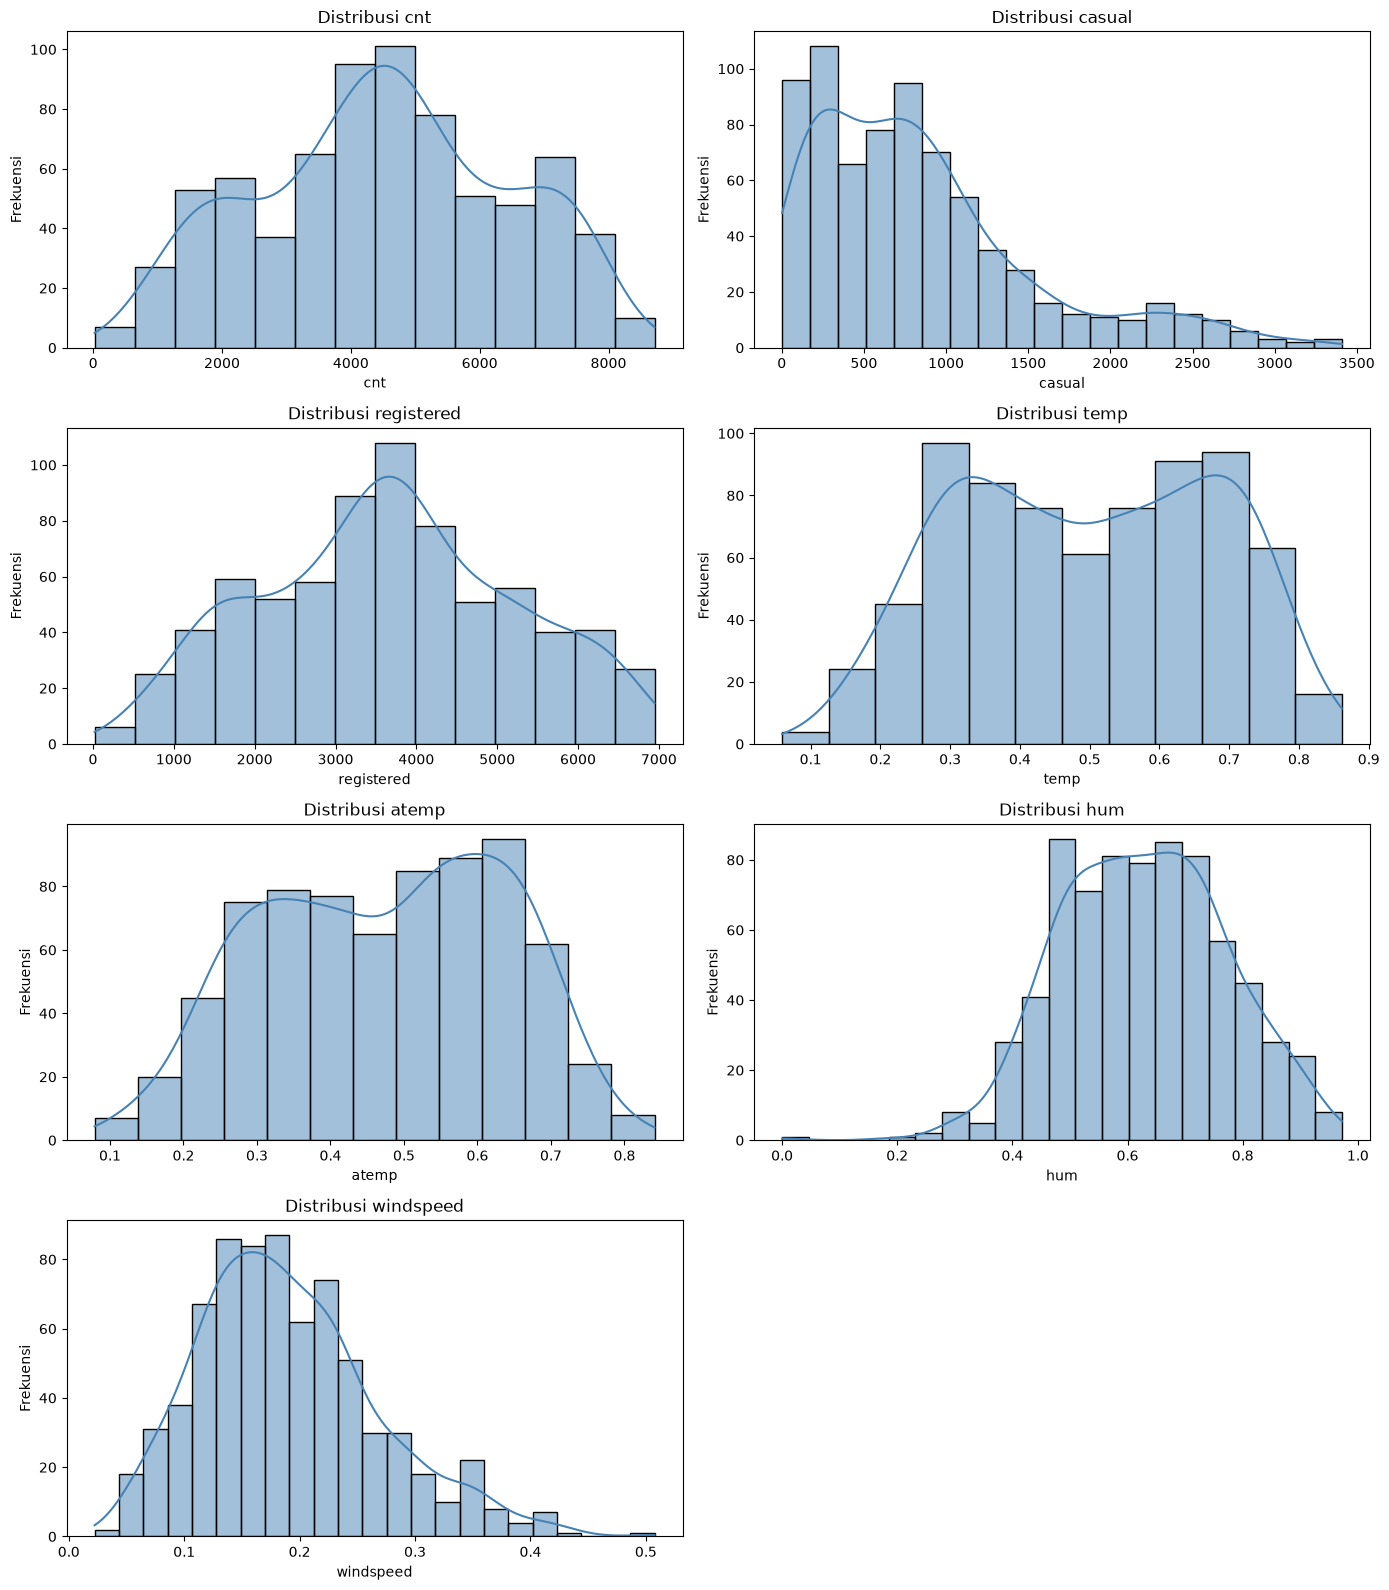

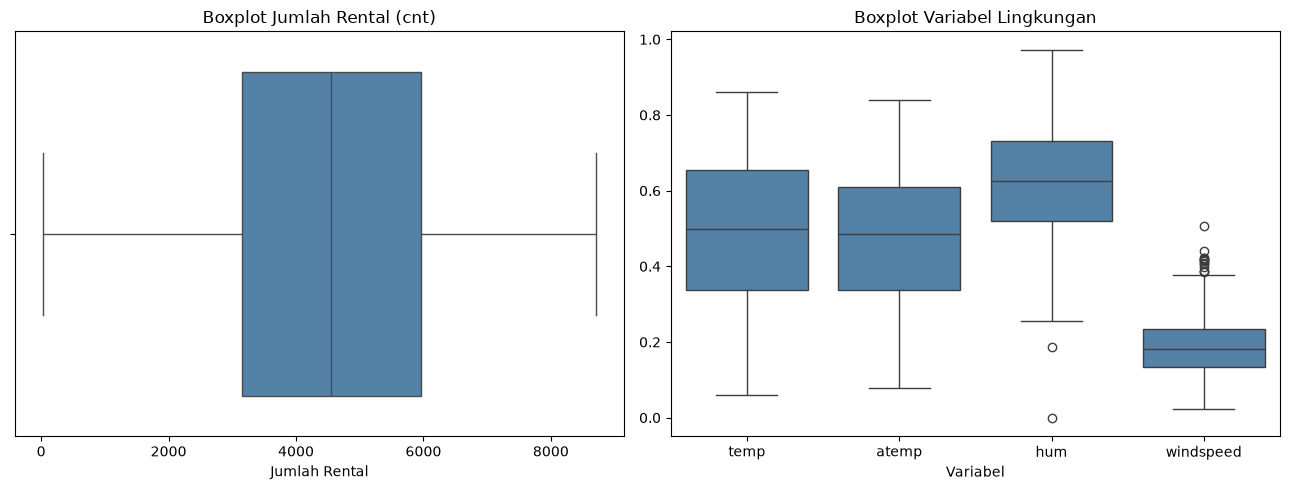

In [6]:
numeric_cols = [
    "cnt", "casual", "registered", "temp", "atemp", "hum", "windspeed"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(day_df[col], kde=True, color="steelblue", ax=ax)
    ax.set_title(f"Distribusi {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frekuensi")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x=day_df["cnt"], color="steelblue", ax=axes[0])
axes[0].set_title("Boxplot Jumlah Rental (cnt)")
axes[0].set_xlabel("Jumlah Rental")
sns.boxplot(data=day_df[["temp", "atemp", "hum", "windspeed"]], color="steelblue", ax=axes[1])
axes[1].set_title("Boxplot Variabel Lingkungan")
axes[1].set_xlabel("Variabel")
plt.tight_layout()
plt.show()


**Insight EDA Univariate:**
- Distribusi "cnt" digunakan untuk melihat tingkat demand harian dan penyebarannya sebelum dilakukan agregasi berdasarkan kategori.
- Boxplot membantu mengidentifikasi nilai yang relatif ekstrem pada demand dan variabel lingkungan.
- Variabel "temp", "atemp", "hum", dan "windspeed" tetap dibaca sebagai nilai normalized sesuai dokumentasi dataset.


### EDA Kategorikal: Distribusi Variabel Kategori

Variabel kategorikal diperiksa untuk mengetahui jumlah observasi pada setiap kategori. Pemeriksaan ini membantu memastikan kategori yang tersedia cukup terwakili sebelum digunakan dalam perbandingan demand.


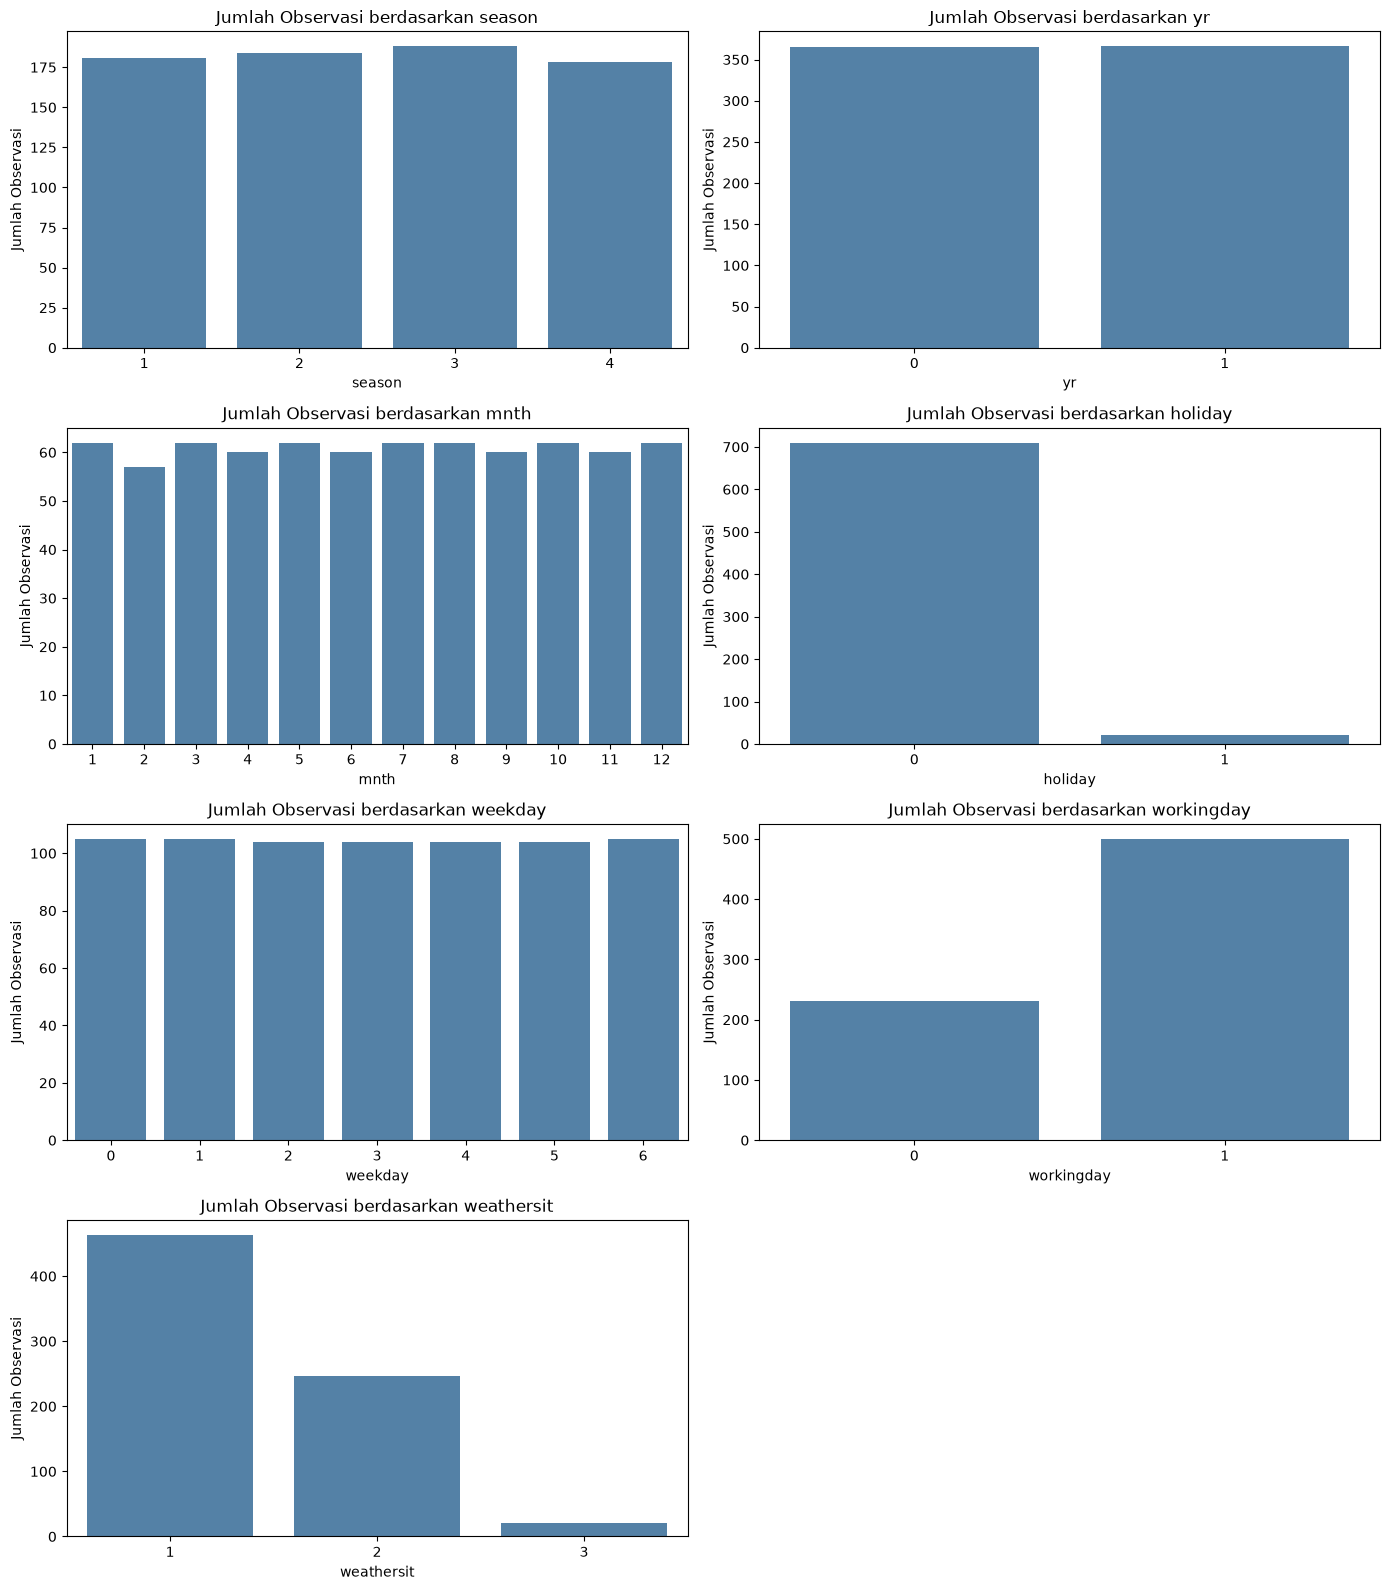

,Jumlah Kategori
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3


In [7]:
categorical_cols = [
    "season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    order = sorted(day_df[col].dropna().unique())
    sns.countplot(data=day_df, x=col, order=order, color="steelblue", ax=ax)
    ax.set_title(f"Jumlah Observasi berdasarkan {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Jumlah Observasi")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

display(day_df[categorical_cols].nunique().rename("Jumlah Kategori").to_frame())


**Insight EDA Kategorikal:**
- Distribusi kategori menunjukkan karakteristik dasar data sebelum perbandingan rental dilakukan.
- "weathersit" memiliki jumlah observasi yang tidak sama antar kategori; kategori cuaca yang jarang muncul perlu diinterpretasikan dengan hati-hati.
- Variabel "workingday" menyediakan dua kelompok yang dapat dibandingkan untuk melihat perbedaan pola demand.


### EDA Multivariate: Hubungan dan Korelasi Variabel

Analisis multivariate digunakan untuk melihat hubungan antara beberapa variabel numerik dan target "cnt". Heatmap memberikan gambaran korelasi secara keseluruhan, sedangkan scatterplot memperlihatkan pola hubungan secara visual.


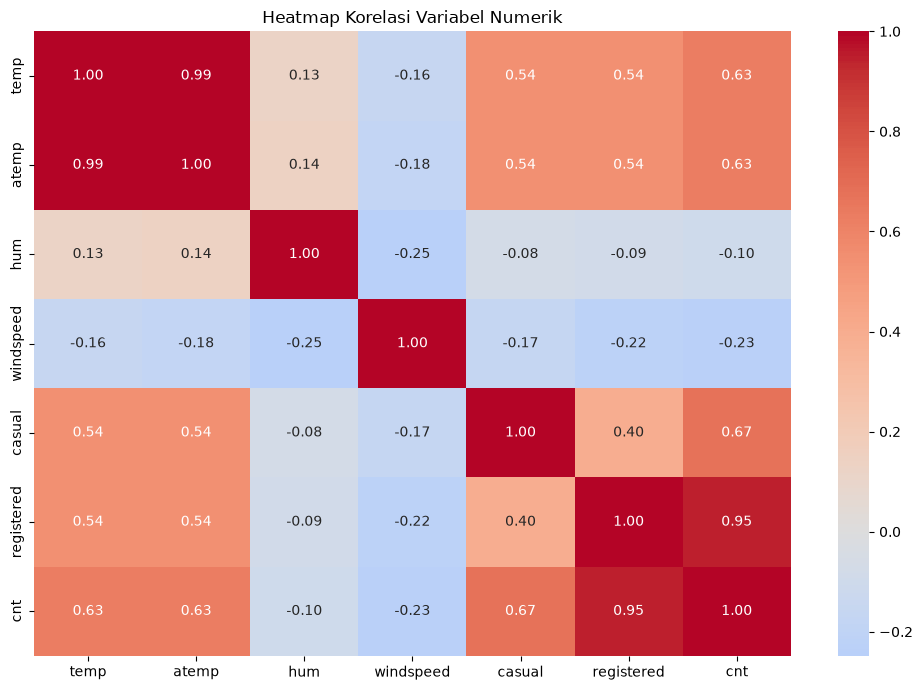

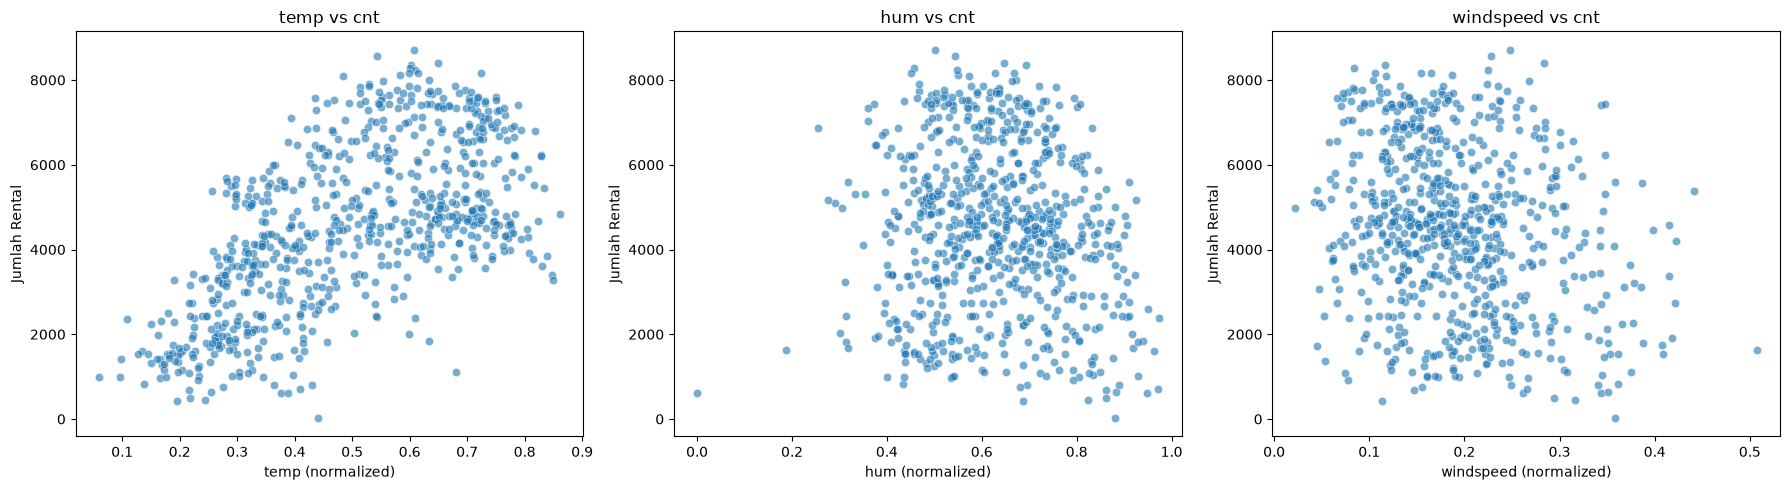

Korelasi dengan cnt:


,cnt
cnt,1.000000
registered,0.945517
casual,0.672804
atemp,0.631066
temp,0.627494
hum,-0.100659
windspeed,-0.234545


In [8]:
corr_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

plt.figure(figsize=(10, 7))
sns.heatmap(
    day_df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Heatmap Korelasi Variabel Numerik")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["temp", "hum", "windspeed"]):
    sns.scatterplot(data=day_df, x=col, y="cnt", alpha=0.6, ax=ax)
    ax.set_title(f"{col} vs cnt")
    ax.set_xlabel(f"{col} (normalized)")
    ax.set_ylabel("Jumlah Rental")
plt.tight_layout()
plt.show()

print("Korelasi dengan cnt:")
display(day_df[corr_cols].corr(numeric_only=True)[["cnt"]].sort_values("cnt", ascending=False))


**Insight EDA Multivariate:**
- "temp" dan "atemp" memiliki korelasi positif dengan "cnt", sedangkan "hum" dan "windspeed" menunjukkan korelasi negatif dalam data harian.
- Korelasi hanya menunjukkan hubungan statistik pada periode pengamatan dan tidak membuktikan hubungan sebab-akibat.
- Hasil EDA multivariate menjadi dasar untuk analisis hubungan cuaca dan lingkungan pada pertanyaan bisnis kedua.


## Visualization & Explanatory Analysis

### Prinsip Desain dan Integritas Visualisasi
Visualisasi pada bagian ini menggunakan:
- label sumbu dan judul yang menjelaskan metrik secara langsung.
- skala yang konsisten untuk perbandingan kategori.
- agregasi rata-rata ketika tujuan analisis adalah membandingkan demand tipikal.
- tanpa efek 3D atau distorsi skala yang dapat mengganggu interpretasi.
- catatan bahwa variabel cuaca tertentu sudah dinormalisasi.
- kategori dan legenda yang diberi nama deskriptif agar mudah dibaca.

### Pertanyaan 1: Bagaimana pola rata-rata rental berdasarkan bulan dan jam selama 2011–2012, serta bagaimana perbedaannya antara working day dan non-working day?


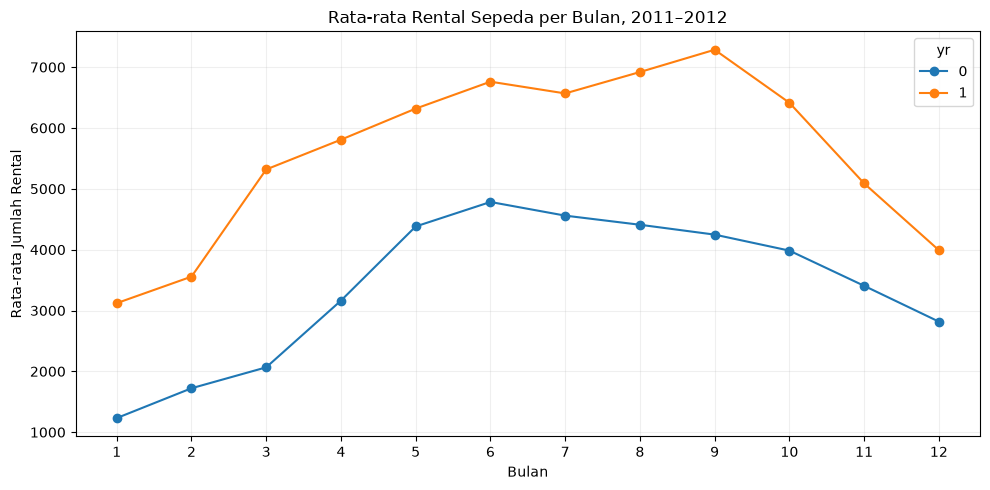

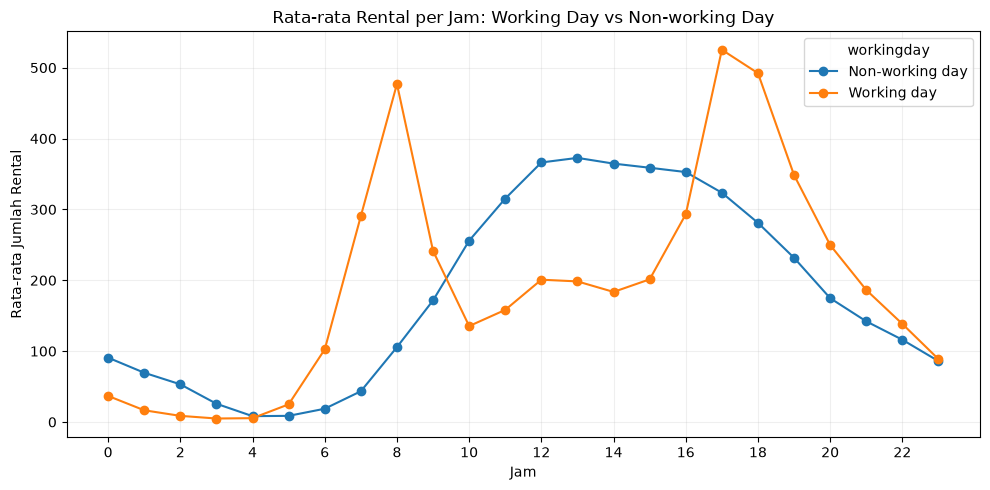

In [9]:
# Visualisasi 1: pola bulanan
monthly_pivot = day_df.groupby(["mnth", "yr"])["cnt"].mean().unstack()
ax = monthly_pivot.plot(marker="o", figsize=(10, 5))
ax.set_title("Rata-rata Rental Sepeda per Bulan, 2011–2012")
ax.set_xlabel("Bulan")
ax.set_ylabel("Rata-rata Jumlah Rental")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Visualisasi 2: pola jam berdasarkan working day
working_hour = hour_df.groupby(["hr", "workingday"])["cnt"].mean().unstack()
ax = working_hour.rename(columns={0: "Non-working day", 1: "Working day"}).plot(
    marker="o", figsize=(10, 5)
)
ax.set_title("Rata-rata Rental per Jam: Working Day vs Non-working Day")
ax.set_xlabel("Jam")
ax.set_ylabel("Rata-rata Jumlah Rental")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Sejauh mana kondisi cuaca dan lingkungan berhubungan dengan jumlah rental selama 2011–2012?


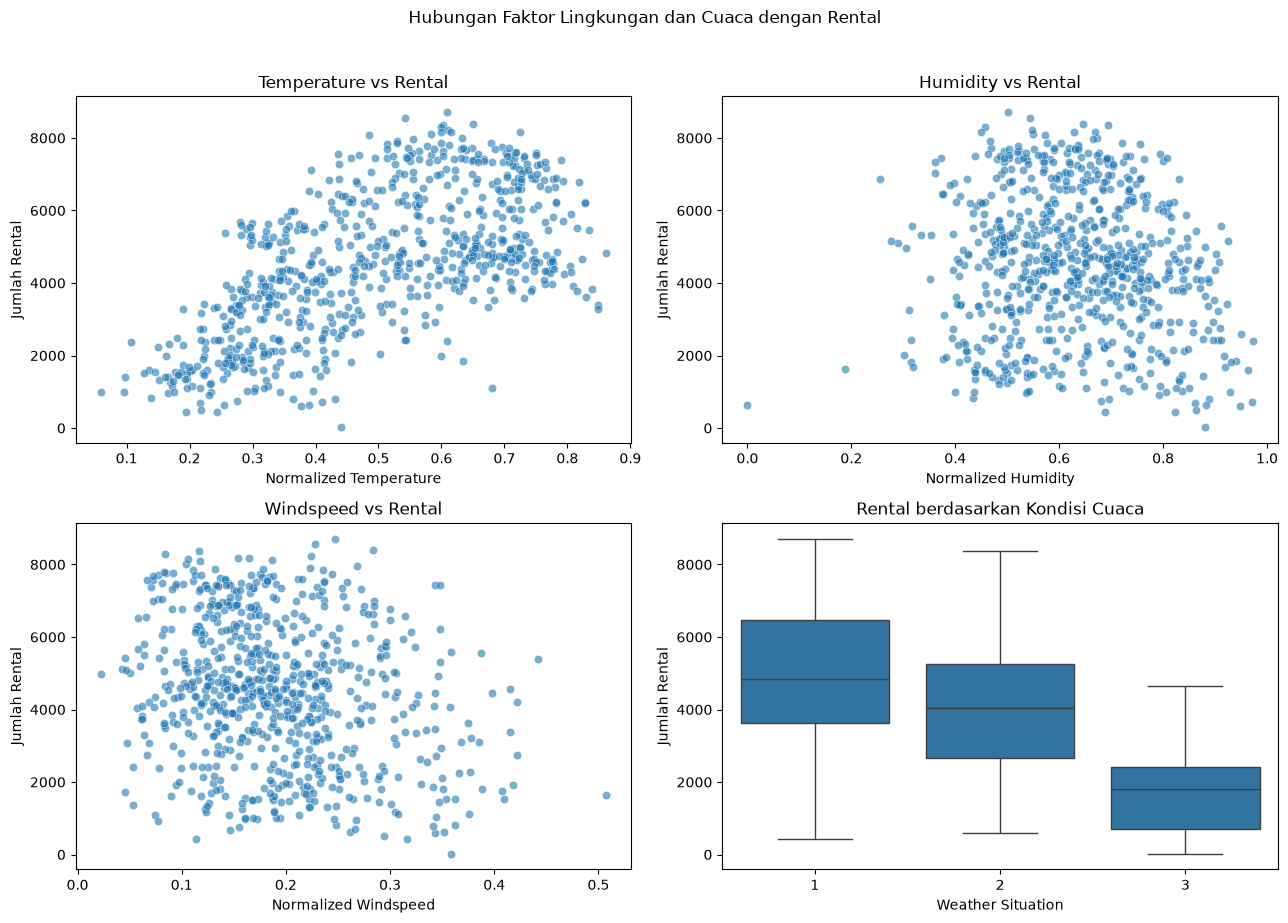

Korelasi Pearson dengan cnt:


,cnt
cnt,1.000000
atemp,0.631066
temp,0.627494
hum,-0.100659
windspeed,-0.234545


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.scatterplot(data=day_df, x="temp", y="cnt", alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title("Temperature vs Rental")
axes[0, 0].set_xlabel("Normalized Temperature")
axes[0, 0].set_ylabel("Jumlah Rental")

sns.scatterplot(data=day_df, x="hum", y="cnt", alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title("Humidity vs Rental")
axes[0, 1].set_xlabel("Normalized Humidity")
axes[0, 1].set_ylabel("Jumlah Rental")

sns.scatterplot(data=day_df, x="windspeed", y="cnt", alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Windspeed vs Rental")
axes[1, 0].set_xlabel("Normalized Windspeed")
axes[1, 0].set_ylabel("Jumlah Rental")

sns.boxplot(data=day_df, x="weathersit", y="cnt", ax=axes[1, 1])
axes[1, 1].set_title("Rental berdasarkan Kondisi Cuaca")
axes[1, 1].set_xlabel("Weather Situation")
axes[1, 1].set_ylabel("Jumlah Rental")

plt.suptitle("Hubungan Faktor Lingkungan dan Cuaca dengan Rental", y=1.02)
plt.tight_layout()
plt.show()

print("Korelasi Pearson dengan cnt:")
display(day_df[["temp", "atemp", "hum", "windspeed", "cnt"]]
        .corr(numeric_only=True)[["cnt"]]
        .sort_values("cnt", ascending=False))

**Insight:**
- Temperatur dan feeling temperature dapat dibandingkan dengan "cnt" untuk melihat arah hubungan dengan demand.
- Kelembapan dan kecepatan angin juga dievaluasi melalui scatterplot dan korelasi, sedangkan "weathersit" dibandingkan antar kategori.
- Korelasi/visualisasi bersifat deskriptif; hasilnya tidak cukup untuk menyatakan bahwa suatu faktor menyebabkan perubahan rental.
- Nilai "temp", "atemp", "hum", dan "windspeed" pada dataset merupakan nilai yang telah dinormalisasi, sehingga sumbu grafik tidak langsung menunjukkan satuan fisik aslinya.


## Analisis Lanjutan: Binning dan Segmentasi Demand (Tanpa Machine Learning)

**Teknik yang digunakan:** "pandas.cut" / "pandas.qcut" untuk membentuk kelompok demand dan kelompok waktu. Teknik ini termasuk **binning/manual grouping**, salah satu pendekatan clustering yang diperbolehkan pada kriteria submission.

Teknik ini relevan karena dataset tidak menyediakan identitas pelanggan, nilai transaksi, atau koordinat/stasiun. Oleh karena itu:
- **RFM Analysis** tidak dapat diterapkan secara valid karena tidak ada "customer_id" dan monetary value.
- **Geospatial Analysis** tidak dapat diterapkan secara valid karena tidak ada koordinat lokasi atau data stasiun.
- **Binning/manual grouping** dapat diterapkan langsung pada "cnt" dan "hr" untuk menghasilkan segmentasi operasional yang dapat ditindaklanjuti.

In [11]:
# 1. Segmentasi tingkat demand harian menggunakan quartile (binning)
q1, q2, q3 = day_df["cnt"].quantile([0.25, 0.50, 0.75])
bins = [-np.inf, q1, q2, q3, np.inf]
labels = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
day_df["demand_level"] = pd.cut(day_df["cnt"], bins=bins, labels=labels, include_lowest=True)

demand_summary = (day_df.groupby("demand_level", observed=False)["cnt"]
                  .agg(Jumlah_Hari="count", Minimum="min", Median="median", Rata_rata="mean", Maksimum="max")
                  .reset_index())
display(demand_summary.round(2))

# 2. Segmentasi jam menjadi empat kelompok operasional
hour_bins = [-1, 5, 11, 17, 23]
hour_labels = ["Dini hari (00–05)", "Pagi (06–11)", "Siang (12–17)", "Malam (18–23)"]
hour_df["hour_group"] = pd.cut(hour_df["hr"], bins=hour_bins, labels=hour_labels)

hour_segment = (hour_df.groupby(["hour_group", "workingday"], observed=False)["cnt"]
                .agg(Rata_rata="mean", Median="median", Jumlah_Observasi="count")
                .reset_index())
hour_segment["jenis_hari"] = hour_segment["workingday"].map({0: "Non-working day", 1: "Working day"})
display(hour_segment.round(2))

# Proporsi working/non-working day pada setiap kelompok waktu
segment_share = pd.crosstab(
    hour_df["hour_group"], hour_df["workingday"], normalize="index"
).rename(columns={0: "Non-working day", 1: "Working day"})
display((segment_share * 100).round(2).rename_axis("Kelompok Jam"))

,demand_level,Jumlah_Hari,Minimum,Median,Rata_rata,Maksimum
0,Rendah,183,22,1944.0,1933.58,3141
1,Sedang,183,3163,3958.0,3916.65,4548
2,Tinggi,182,4549,5093.0,5128.13,5936
3,Sangat Tinggi,183,5976,7013.0,7042.45,8714


,hour_group,workingday,Rata_rata,Median,Jumlah_Observasi,jenis_hari
0,Dini hari (00–05),0,43.00,27.0,1364,Non-working day
1,Dini hari (00–05),1,16.44,10.0,2912,Working day
2,Pagi (06–11),0,151.97,99.5,1384,Non-working day
3,Pagi (06–11),1,234.21,187.0,2976,Working day
4,Siang (12–17),0,356.45,358.0,1386,Non-working day
5,Siang (12–17),1,267.21,226.0,2989,Working day
6,Malam (18–23),0,171.92,144.0,1380,Non-working day
7,Malam (18–23),1,250.62,197.0,2988,Working day


workingday,Non-working day,Working day
Kelompok Jam,,
Dini hari (00–05),31.90,68.10
Pagi (06–11),31.74,68.26
Siang (12–17),31.68,68.32
Malam (18–23),31.59,68.41


### Interpretasi Segmentasi Demand
Segmentasi membagi hari ke dalam empat kelompok berdasarkan kuartil jumlah rental aktual. Ini bukan model prediktif dan tidak menggunakan algoritma machine learning.

Kelompok waktu (Dini hari, Pagi, Siang, Malam) dibuat berdasarkan aturan jam yang transparan. Hasilnya dapat digunakan untuk membandingkan rata-rata dan median demand antar kelompok serta melihat perbedaan working day dan non-working day.

**Catatan:** batas kuartil merupakan batas yang diturunkan dari distribusi dataset 2011–2012, sehingga segmentasi ini bersifat deskriptif untuk periode analisis tersebut.

In [12]:
def prepare_model_data(df, hourly=False):
    d = df.copy()
    drop_cols = ["dteday", "cnt", "casual", "registered", "instant", "demand_level", "hour_group"]
    d = d.drop(columns=[c for c in drop_cols if c in d.columns])

    if "date_ordinal" not in d.columns:
        d["date_ordinal"] = (df["dteday"] - day_df["dteday"].min()).dt.days
        d["month_sin"] = np.sin(2 * np.pi * d["mnth"] / 12)
        d["month_cos"] = np.cos(2 * np.pi * d["mnth"] / 12)

    if hourly and "hr_sin" not in d.columns:
        d["hr_sin"] = np.sin(2 * np.pi * d["hr"] / 24)
        d["hr_cos"] = np.cos(2 * np.pi * d["hr"] / 24)

    return d

def build_model(df, hourly=False):
    X = prepare_model_data(df, hourly)
    y = df["cnt"]
    cut = int(len(df) * 0.8)

    categorical = [c for c in
                    ["season", "yr", "mnth", "hr", "holiday",
                     "weekday", "workingday", "weathersit"]
                    if c in X.columns]

    preprocessor = ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), categorical)],
        remainder="passthrough"
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", GradientBoostingRegressor(
            n_estimators=300, max_depth=3,
            learning_rate=0.03, loss="huber",
            random_state=42
        ))
    ])

    model.fit(X.iloc[:cut], y.iloc[:cut])
    pred = model.predict(X.iloc[cut:])

    return model, y.iloc[cut:], pred

daily_model, y_daily_test, pred_daily = build_model(day_df, hourly=False)
hour_model, y_hour_test, pred_hour = build_model(hour_df, hourly=True)

evaluation = pd.DataFrame({
    "Dataset": ["Harian", "Per Jam"],
    "MAE": [
        mean_absolute_error(y_daily_test, pred_daily),
        mean_absolute_error(y_hour_test, pred_hour)
    ],
    "RMSE": [
        mean_squared_error(y_daily_test, pred_daily) ** 0.5,
        mean_squared_error(y_hour_test, pred_hour) ** 0.5
    ],
    "R2": [
        r2_score(y_daily_test, pred_daily),
        r2_score(y_hour_test, pred_hour)
    ]
})

display(evaluation.round(3))

# Deteksi anomali dilakukan hanya pada periode uji (20% data terakhir)
# agar residual tidak berasal dari data yang digunakan untuk melatih model.
X_all = prepare_model_data(day_df, hourly=False)
cut = int(len(day_df) * 0.8)
cat = [c for c in ["season", "yr", "mnth", "holiday", "weekday",
                   "workingday", "weathersit"] if c in X_all.columns]

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat)],
    remainder="passthrough"
)

anomaly_model = Pipeline([
    ("preprocessor", pre),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300, max_depth=3,
        learning_rate=0.03, loss="huber",
        random_state=42
    ))
])

anomaly_model.fit(X_all.iloc[:cut], day_df["cnt"].iloc[:cut])

day_anomaly = day_df.iloc[cut:][["dteday", "cnt", "weathersit",
                                  "holiday", "workingday"]].copy()
day_anomaly["pred"] = anomaly_model.predict(X_all.iloc[cut:])
day_anomaly["resid"] = day_anomaly["cnt"] - day_anomaly["pred"]

median_resid = day_anomaly["resid"].median()
mad = np.median(np.abs(day_anomaly["resid"] - median_resid))
day_anomaly["robust_z"] = (
    0.6745 * (day_anomaly["resid"] - median_resid) / (mad if mad != 0 else 1)
)

anomalies = (day_anomaly[day_anomaly["robust_z"].abs() > 3.5]
             .sort_values("robust_z"))

display(anomalies[[
    "dteday", "cnt", "pred", "resid", "robust_z",
    "weathersit", "holiday", "workingday"
]].head(15))


,Dataset,MAE,RMSE,R2
0,Harian,721.861,1046.779,0.688
1,Per Jam,71.802,101.725,0.787


,dteday,cnt,pred,resid,robust_z,weathersit,holiday,workingday
723,2012-12-24,920,4449.324278,-3529.324278,-5.779497,2,0,1
691,2012-11-22,2425,5738.553379,-3313.553379,-5.440370,1,1,0
667,2012-10-29,22,3245.727630,-3223.727630,-5.299191,3,0,1
724,2012-12-25,1013,4230.489424,-3217.489424,-5.289387,2,1,0
722,2012-12-23,1787,4655.272619,-2868.272619,-4.740523,1,0,0
668,2012-10-30,1096,3895.199861,-2799.199861,-4.631961,2,0,1
728,2012-12-29,1341,4097.267757,-2756.267757,-4.564485,2,0,0
596,2012-08-19,4549,7247.841898,-2698.841898,-4.474229,2,0,0
694,2012-11-25,2424,5071.729675,-2647.729675,-4.393895,1,0,0
645,2012-10-07,3510,5912.556769,-2402.556769,-4.008557,2,0,0


**Insight:**
- Evaluasi menggunakan pembagian kronologis 80% data awal sebagai training dan 20% data terakhir sebagai testing. "casual" dan "registered" tidak digunakan sebagai prediktor karena keduanya merupakan komponen langsung dari "cnt".
- Dengan konfigurasi model yang sama, hasil evaluasi adalah **R² = 0,688** pada data harian dan **R² = 0,787** pada data per jam, MAE masing-masing sekitar **721,861** dan **71,794**, sedangkan RMSE sekitar **1.046,779** dan **101,713**.
- Deteksi anomali menggunakan robust z-score residual dengan ambang **|z| > 3,5** dan hanya diterapkan pada periode testing.
- Kandidat anomali menunjukkan tanggal dengan rental aktual jauh di bawah/di atas nilai yang diprediksi. Kandidat tersebut merupakan **sinyal untuk investigasi**, bukan bukti otomatis adanya event tertentu.


## Conclusion & Recommendation

### Conclusion & Recommendation

**Pertanyaan 1 — Pola waktu dan working day**

- **Evidence:** Rata-rata rental bulanan tertinggi jika seluruh periode 2011–2012 digabungkan terjadi pada bulan Juni, yaitu sekitar **5.772 rental/hari**. Pada data per jam, working day memiliki puncak rata-rata pada **17:00 sebesar 525 rental/jam**, sedangkan non-working day memiliki puncak pada **13:00 sebesar 373 rental/jam**. Rata-rata rental harian juga meningkat dari **3.406 pada 2011** menjadi **5.600 pada 2012**.
- **Trend Analysis:** Pola working day menunjukkan konsentrasi demand pada jam berangkat dan terutama sore hari, sedangkan non-working day lebih terkonsentrasi pada sekitar tengah hari. Secara tahunan, tingkat demand 2012 lebih tinggi daripada 2011, sehingga pola waktu perlu dibaca bersama perubahan tingkat demand antar tahun.
- **Actionable Insight:** Pengelola dapat menggunakan informasi jam puncak tersebut sebagai dasar untuk memprioritaskan ketersediaan sepeda dan kesiapan operasional pada sore hari working day serta sekitar tengah hari non-working day. Perencanaan juga perlu mempertimbangkan bahwa demand pada 2012 lebih tinggi daripada 2011.

**Pertanyaan 2 — Hubungan kondisi cuaca dan lingkungan dengan rental**

- **Evidence:** Korelasi Pearson dengan "cnt" adalah **0,627 untuk temp**, **0,631 untuk atemp**, **-0,101 untuk hum**, dan **-0,235 untuk windspeed**. Berdasarkan "weathersit", rata-rata rental pada kondisi **Clear/Few clouds** sekitar **4.877 rental/hari**, sedangkan pada **Light Snow/Rain** sekitar **1.803 rental/hari**. Kategori Light Snow/Rain hanya memiliki **21 observasi**, sehingga perbandingan kategori ini perlu dibaca secara hati-hati.
- **Trend Analysis:** Rental cenderung lebih tinggi pada nilai temperatur yang lebih tinggi dalam periode pengamatan, sementara kelembapan dan kecepatan angin memiliki hubungan negatif yang lebih lemah. Demand juga berbeda menurut kondisi cuaca, dengan rata-rata rental lebih rendah pada kondisi cuaca yang lebih buruk.
- **Actionable Insight:** Kondisi cuaca dan lingkungan dapat digunakan sebagai konteks tambahan ketika memperkirakan kebutuhan rental dan menyiapkan operasional. Namun, temuan ini bersifat asosiatif/deskriptif dan tidak dapat digunakan untuk menyatakan bahwa cuaca secara langsung menyebabkan perubahan rental.

**Pertanyaan 3 — Segmentasi demand**

- **Evidence:** Binning kuartil membagi hari menjadi empat level demand—Rendah, Sedang, Tinggi, dan Sangat Tinggi—berdasarkan distribusi "cnt" 2011–2012. Kelompok waktu juga dibagi menjadi Dini hari (00–05), Pagi (06–11), Siang (12–17), dan Malam (18–23).
- **Trend Analysis:** Segmentasi memungkinkan demand dibandingkan secara konsisten antar kelompok tingkat rental dan periode waktu tanpa menggunakan algoritma machine learning.
- **Actionable Insight:** Hasil segmentasi dapat digunakan sebagai ringkasan operasional untuk mengenali periode yang perlu dipantau lebih ketat, terutama ketika digabungkan dengan informasi working day dan kondisi cuaca.

**Analisis tambahan:** Regresi dan deteksi anomali digunakan sebagai analisis eksploratif tambahan. Anomali ditentukan dari residual pada 20% periode terakhir dengan robust z-score; kandidat anomali merupakan sinyal untuk investigasi dan tetap perlu divalidasi menggunakan informasi eksternal sebelum dikaitkan dengan event tertentu.


**Rekomendasi Action Item:**
- Gunakan pola per jam dan perbedaan working day/non-working day untuk membantu perencanaan ketersediaan sepeda pada periode demand tinggi.
- Gunakan informasi cuaca sebagai variabel pendukung dalam perencanaan demand, bukan sebagai satu-satunya dasar keputusan.
- Pantau residual prediksi pada periode baru untuk mendeteksi penurunan atau lonjakan rental yang tidak biasa.
- Validasi setiap kandidat anomali dengan informasi eksternal seperti cuaca ekstrem, hari libur, acara kota, atau gangguan transportasi sebelum menetapkan penyebab.
- Gunakan dashboard Streamlit sebagai media monitoring interaktif agar pola waktu, cuaca, performa model, dan kandidat anomali dapat dieksplorasi.


## Dokumentasi Integritas dan Keterbatasan Analisis

- Dataset mencakup periode **2011–2012** sehingga kesimpulan terutama berlaku untuk periode tersebut.
- "temp", "atemp", "hum", dan "windspeed" merupakan nilai normalized; jangan membaca nilainya sebagai °C, persen kelembapan, atau satuan fisik lainnya secara langsung.
- "casual" dan "registered" tidak digunakan sebagai prediktor karena merupakan komponen dari "cnt".
- Hubungan yang ditampilkan melalui EDA dan korelasi bersifat asosiatif/deskriptif, bukan bukti kausalitas.
- Segmentasi demand menggunakan binning yang transparan dan tidak memakai machine learning.
- Anomaly detection pada analisis tambahan digunakan sebagai sinyal investigasi, bukan penetapan otomatis penyebab event.

## Dashboard Streamlit

Dashboard dibuat menggunakan **Streamlit** sebagai media penyampaian hasil analisis secara interaktif. Dashboard menyediakan filter tahun, bulan, dan kondisi cuaca; KPI rental; tren harian; pola per jam; perbandingan working day; hubungan cuaca; **segmentasi demand berbasis binning**; evaluasi regresi; serta kandidat anomali.